# M4 — CNN Architecture & Transfer Learning
**DR-Triage · Diabetic Retinopathy Stage Detection**

Covers rubric item 4 (*CNN Architecture & Transfer Learning*, 20 marks). We build
**one shared EfficientNetV2-S backbone + CBAM attention feeding three heads**:

| head | output | activation | job |
|---|---|---|---|
| stage | 5 logits | softmax | which of the 5 severity grades |
| ordinal (CORAL) | 4 logits | sigmoid | the *ordering* — P(stage > k) for k = 0..3 |
| referable | 1 logit | sigmoid | clinical decision: refer to ophthalmologist? (stage >= 2) |

This notebook: draws the architecture, counts parameters, **walks one real image
through every stage with pictures**, then does a full forward + loss + backward
sanity check. All in `src/model.py` and `src/losses.py`.

In [1]:
# --- Setup ---------------------------------------------------------------------
import sys, os, glob, shutil
from pathlib import Path

PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve()); break
if PROJECT is None:
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1]); PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
assert PROJECT, "Upload dr-triage.zip via Add Input -> Upload, then re-run."
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import cv2

from src.data import load_config, load_splits, load_labels, APTOSDataset, DatasetConfig
from src.preprocess import make_preprocessor
from src.augment import build_eval_aug, per_class_weights
from src.model import DRModel, count_parameters, predict_stage
from src.losses import MultiTaskLoss

cfg = load_config()
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
pre = make_preprocessor(cfg)
MEAN, STD = cfg["image"]["mean"], cfg["image"]["std"]
S = cfg["image"]["size_stage1"]
torch.manual_seed(cfg["seed"])

def read_rgb(p):
    im = cv2.imread(str(p)); return None if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

try:
    train = load_splits(cfg)["train"]
except FileNotFoundError:
    train = load_labels(cfg)
print("device check — CUDA:", torch.cuda.is_available(), "| MPS:", torch.backends.mps.is_available())

/Users/ilmeedesilva/Computer Vision/dr-triage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device check — CUDA: False | MPS: True


## 4.1  Architecture at a glance

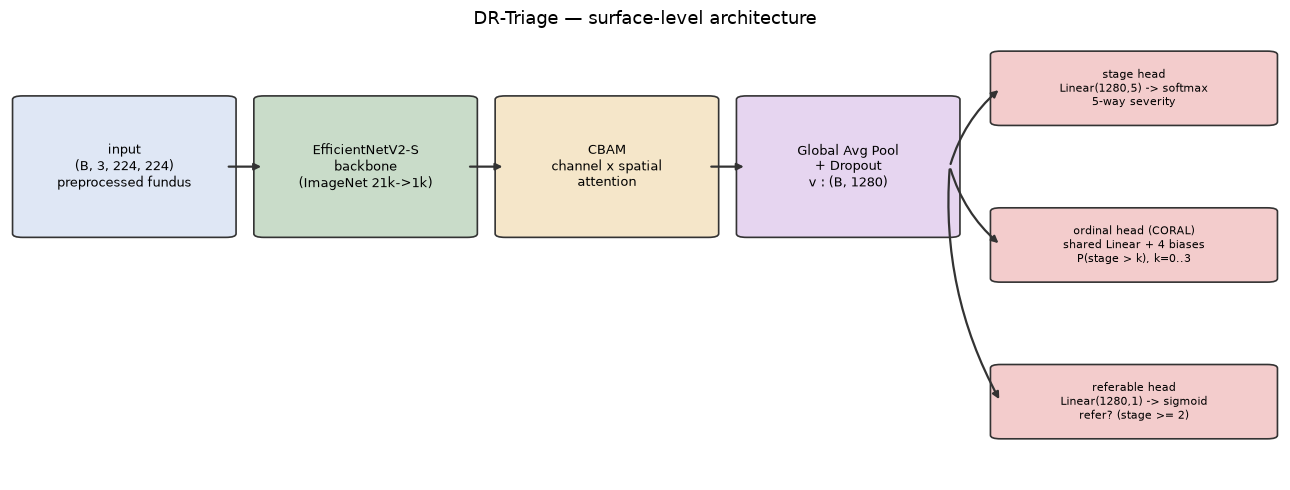

In [2]:
def box(ax, x, y, w, h, text, fc, fs=9):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008",
                                         fc=fc, ec="#333", lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs)

def arrow(ax, x0, y0, x1, y1, rad=0.0):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#333",
                                connectionstyle=f"arc3,rad={rad}"))

fig, ax = plt.subplots(figsize=(13, 5)); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

spine = [
    (0.01, "input\n(B, 3, 224, 224)\npreprocessed fundus", "#dfe7f5"),
    (0.20, "EfficientNetV2-S\nbackbone\n(ImageNet 21k->1k)", "#c9dcc9"),
    (0.39, "CBAM\nchannel x spatial\nattention", "#f5e6c9"),
    (0.58, "Global Avg Pool\n+ Dropout\nv : (B, 1280)", "#e6d5f0"),
]
for x, txt, col in spine:
    box(ax, x, 0.55, 0.16, 0.30, txt, col)
for (x0, *_), (x1, *_) in zip(spine, spine[1:]):
    arrow(ax, x0 + 0.16, 0.70, x1, 0.70)

heads = [
    (0.80, "stage head\nLinear(1280,5) -> softmax\n5-way severity", "#f3cccc"),
    (0.45, "ordinal head (CORAL)\nshared Linear + 4 biases\nP(stage > k), k=0..3", "#f3cccc"),
    (0.10, "referable head\nLinear(1280,1) -> sigmoid\nrefer? (stage >= 2)", "#f3cccc"),
]
for y, txt, col in heads:
    box(ax, 0.78, y, 0.21, 0.15, txt, col, fs=8)
    arrow(ax, 0.74, 0.70, 0.78, y + 0.075, rad=0.15 if y < 0.5 else -0.15)

ax.set_title("DR-Triage — surface-level architecture", fontsize=13)
plt.tight_layout(); plt.savefig(FIG / "04_architecture.png", dpi=150, bbox_inches="tight"); plt.show()

## 4.2  Build the model & parameter budget

`num_classes=0, global_pool=''` makes the timm backbone return the raw feature
map so we can attach CBAM before pooling. Pretrained ImageNet-21k->1k weights
download on first run (~82 MB); set `pretrained=False` if offline.

In [3]:
try:
    model = DRModel(cfg, pretrained=True); weights = "ImageNet-21k->1k (pretrained)"
except Exception as e:
    print("pretrained unavailable:", e); model = DRModel(cfg, pretrained=False); weights = "random init"
model.eval()

with torch.no_grad():
    fmap = model.forward_features(torch.randn(1, 3, S, S))
p = count_parameters(model)
print(f"backbone      : {cfg['model']['backbone']}")
print(f"weights       : {weights}")
print(f"feature map   : {tuple(fmap.shape)}   (stride {S // fmap.shape[-1]})")
print(f"embedding dim : {model.feat_dim}")
print(f"\nparameters:")
for k, v in p.items():
    print(f"  {k:16s}: {v/1e6:7.2f} M")
print(f"\nCBAM + heads are only {p['heads_and_cbam']/p['total']*100:.1f}% of the model — "
      f"the backbone does the heavy lifting (that is the point of transfer learning).")

backbone      : tf_efficientnetv2_s.in21k_ft_in1k
weights       : ImageNet-21k->1k (pretrained)
feature map   : (1, 1280, 7, 7)   (stride 32)
embedding dim : 1280

parameters:
  total           :   20.39 M
  trainable       :   20.39 M
  backbone        :   20.18 M
  heads_and_cbam  :    0.22 M

CBAM + heads are only 1.1% of the model — the backbone does the heavy lifting (that is the point of transfer learning).


## 4.3  What happens to one image at each stage

Left to right: the preprocessed input, six of the backbone's 1280 feature-map
channels (bright = strongly activated), the **CBAM spatial-attention map** (where
the network decides to look), and the three head outputs.

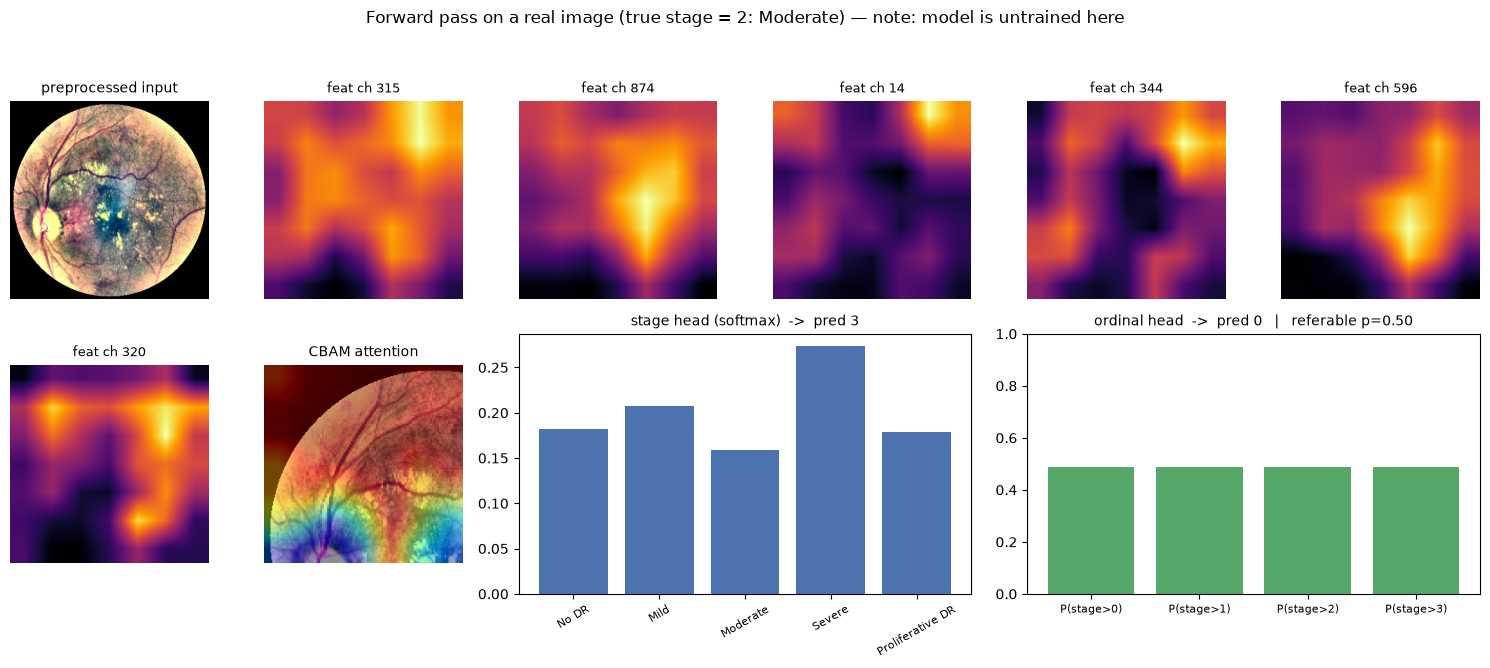

In [4]:
row = train[train["stage"] == 2].iloc[0]           # a Moderate-DR example
img = pre(read_rgb(row["path"]))
ten = build_eval_aug(S, MEAN, STD)(image=img)["image"].unsqueeze(0)

model.eval()
with torch.no_grad():
    feats = model.forward_features(ten)               # (1, 1280, h, w)
    spatial = model.cbam._last_spatial               # (1, 1, h, w) cached by CBAM
    out = model(ten)

top = feats[0].mean(dim=(1, 2)).topk(6).indices       # 6 most-active channels

fig = plt.figure(figsize=(15, 6.5))
gs = fig.add_gridspec(2, 6)

ax = fig.add_subplot(gs[0, 0]); ax.imshow(img); ax.set_title("preprocessed input", fontsize=10); ax.axis("off")
for i, ch in enumerate(top):
    a = fig.add_subplot(gs[0, 1 + i] if i < 5 else gs[1, 0])
    fm = feats[0, ch].cpu().numpy()
    a.imshow(cv2.resize(fm, (S, S)), cmap="inferno"); a.set_title(f"feat ch {int(ch)}", fontsize=9); a.axis("off")

a = fig.add_subplot(gs[1, 1])
sp = cv2.resize(spatial[0, 0].cpu().numpy(), (S, S))
a.imshow(img); a.imshow(sp, cmap="jet", alpha=0.45); a.set_title("CBAM attention", fontsize=10); a.axis("off")

pr = predict_stage(out)
a = fig.add_subplot(gs[1, 2:4])
a.bar(range(5), out["stage"].softmax(1)[0].detach().numpy(), color="#4c72b0")
a.set_xticks(range(5)); a.set_xticklabels([cfg["classes"][k] for k in range(5)], rotation=30, fontsize=8)
a.set_title(f"stage head (softmax)  ->  pred {int(pr['softmax_pred'])}", fontsize=10)

a = fig.add_subplot(gs[1, 4:6])
a.bar(range(4), out["ordinal"].sigmoid()[0].detach().numpy(), color="#55a868")
a.set_xticks(range(4)); a.set_xticklabels([f"P(stage>{k})" for k in range(4)], fontsize=8)
a.set_ylim(0, 1)
a.set_title(f"ordinal head  ->  pred {int(pr['ordinal_pred'])}   |   referable p="
            f"{float(pr['referable_prob']):.2f}", fontsize=10)

fig.suptitle(f"Forward pass on a real image (true stage = {row['stage']}: {row['stage_name']}) "
             f"— note: model is untrained here", y=1.02, fontsize=12)
plt.tight_layout(); plt.savefig(FIG / "04_forward_walkthrough.png", dpi=150, bbox_inches="tight"); plt.show()

## 4.4  Loss function

`MultiTaskLoss` = weighted sum (weights from `config.yaml: train.loss_weights`):

| term | on | purpose |
|---|---|---|
| **Focal** (gamma 2) | stage head | down-weight easy majority examples; with effective-number class weights |
| **CORAL BCE** | ordinal head | learn the ordering; rank-consistent by construction |
| **BCE** | referable head | the refer / no-refer decision |
| **Soft QWK** ( = 1 - kappa ) | stage head | directly optimise *Quadratic Weighted Kappa*, the clinical grading-agreement metric — penalises far-off mistakes more than near ones |

It also supports MixUp/CutMix via `targets_b`, `lam`.

In [5]:
# Full forward + loss + backward on a real batch of 8.
ds = APTOSDataset(train.sample(64, random_state=0).reset_index(drop=True),
                  DatasetConfig(image_size=S, preprocess=pre, transform=build_eval_aug(S, MEAN, STD)))
xb, yb = next(iter(torch.utils.data.DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)))
print("batch:", tuple(xb.shape), "| targets:", {k: tuple(v.shape) for k, v in yb.items()})

cw = torch.tensor(per_class_weights(train, 5, beta=cfg["augment"]["class_weight_beta"]))
crit = MultiTaskLoss(cfg, class_weight=cw)

model.train()
model.zero_grad()
out = model(xb)
loss, parts = crit(out, yb)
loss.backward()

bb, hd = model.group_parameters()
bb_g = sum(float(p.grad.abs().sum()) for p in bb if p.grad is not None)
hd_g = sum(float(p.grad.abs().sum()) for p in hd if p.grad is not None)
print("\nloss components:", {k: round(float(v), 4) for k, v in parts.items()})
print(f"total loss      : {float(loss.detach()):.4f}  (finite: {torch.isfinite(loss).item()})")
print(f"grad flow       : backbone |g|={bb_g:.2e}   heads+cbam |g|={hd_g:.2e}")
print("sanity check     : PASS" if torch.isfinite(loss) and bb_g > 0 and hd_g > 0 else "FAIL")

batch: (8, 3, 224, 224) | targets: {'stage': (8,), 'ordinal': (8, 4), 'referable': (8,)}

loss components: {'stage': 0.8389, 'ordinal': 3.0175, 'referable': 0.7154, 'qwk': 1.0486, 'total': 3.2296}
total loss      : 3.2296  (finite: True)
grad flow       : backbone |g|=3.14e+04   heads+cbam |g|=1.46e+03
sanity check     : PASS


## 4.5  Design justification  *(report-ready)*

**Why EfficientNetV2-S (not ResNet-50 / VGG-16).** EfficientNetV2 uses compound
scaling and Fused-MBConv blocks: at ~20 M parameters it matches ResNet-50-level
accuracy while training roughly 2-3x faster and using less memory, so we can
fine-tune at 380 px on a single GPU and still run several architecture
experiments. VGG-16 (138 M params) is far larger for lower accuracy.

**Why transfer learning.** ~2.5 k training images is far too few to learn good
low-level vision filters from scratch. ImageNet-pretrained weights already encode
edges, blobs and texture; we only need to re-purpose the higher layers for retinal
lesions. CBAM + heads are just 1.1% of the parameters — everything else is
transferred and then fine-tuned.

**Why CBAM.** Fundus images are ~50% uniform background. A light channel+spatial
attention module (<0.2 M params) lets the network suppress that background and
amplify small focal lesions; it also produces a sharper Grad-CAM in M6.

**Why multi-task with an ordinal head.** The five DR grades are *ordered*. A plain
softmax treats "predict No-DR when truth is Proliferative" the same as "predict
Moderate when truth is Severe" — clinically absurd. The CORAL head models
P(stage > k) with shared weights, so predictions are rank-consistent, and the
soft-QWK loss term explicitly penalises predictions that are far from the truth.
The referable head exposes the one decision a screening clinic actually acts on.

## Milestone status
- [x] M1 EDA+split · [x] M2 preprocessing · [x] M3 augmentation+balancing
- [x] **M4 — model (EfficientNetV2-S + CBAM + 3 heads) + losses**, sanity check PASS
- [ ] M5 — two-phase training + 3-fold stratified CV → `notebooks/05_train.ipynb`